# PROJET : Consommation essence en France

#### Membres du groupe
- ADOUSSINGANDE Céline
- COMLAN Yayra

In [3]:
import pandas as pd

## Préparation des données
### Etape 1
-  
Collecte des données

In [26]:
df_essence = pd.read_csv("Prix2023.csv.gz", sep=';',header=None, compression='gzip')
df_essence.head(5)

,0,1,2,3,4,5,6,7,8
0,1000001,1000,R,4620100.0,519800.0,2023-01-02T07:53:26,1.0,Gazole,1.867
1,1000001,1000,R,4620100.0,519800.0,2023-01-05T09:33:37,1.0,Gazole,1.877
2,1000001,1000,R,4620100.0,519800.0,2023-01-09T14:51:49,1.0,Gazole,1.875
3,1000001,1000,R,4620100.0,519800.0,2023-01-11T09:23:54,1.0,Gazole,1.859
4,1000001,1000,R,4620100.0,519800.0,2023-01-13T09:07:40,1.0,Gazole,1.862


In [27]:
# Ajout des noms des colonnes
df_essence.columns = ['id_pdv', 'code_postal', 'population', 'latitude', 'longitude', 'date', 'carburant_id', 'carburant_nom', 'prix']
df_essence.head()

,id_pdv,code_postal,population,latitude,longitude,date,carburant_id,carburant_nom,prix
0,1000001,1000,R,4620100.0,519800.0,2023-01-02T07:53:26,1.0,Gazole,1.867
1,1000001,1000,R,4620100.0,519800.0,2023-01-05T09:33:37,1.0,Gazole,1.877
2,1000001,1000,R,4620100.0,519800.0,2023-01-09T14:51:49,1.0,Gazole,1.875
3,1000001,1000,R,4620100.0,519800.0,2023-01-11T09:23:54,1.0,Gazole,1.859
4,1000001,1000,R,4620100.0,519800.0,2023-01-13T09:07:40,1.0,Gazole,1.862


In [30]:
df_essence = df_essence.assign(prix=lambda df_essence: df_essence['prix'] / 1000)

In [32]:
# Convertion la colonne 'date' au format datetime (remplacez 'date' par le nom réel de la colonne)
df_essence['date'] = pd.to_datetime(df_essence['date'], errors='coerce')  
df_essence['année'] = df_essence['date'].dt.year
df_essence['mois'] = df_essence['date'].dt.month
df_essence['semaine'] = df_essence['date'].dt.isocalendar().week 
df_essence.head()

,id_pdv,code_postal,population,latitude,longitude,date,carburant_id,carburant_nom,prix,année,mois,semaine
0,1000001,1000,R,4620100.0,519800.0,2023-01-02 07:53:26,1.0,Gazole,0.001867,2023.0,1.0,1
1,1000001,1000,R,4620100.0,519800.0,2023-01-05 09:33:37,1.0,Gazole,0.001877,2023.0,1.0,1
2,1000001,1000,R,4620100.0,519800.0,2023-01-09 14:51:49,1.0,Gazole,0.001875,2023.0,1.0,2
3,1000001,1000,R,4620100.0,519800.0,2023-01-11 09:23:54,1.0,Gazole,0.001859,2023.0,1.0,2
4,1000001,1000,R,4620100.0,519800.0,2023-01-13 09:07:40,1.0,Gazole,0.001862,2023.0,1.0,2


In [34]:
# Division des colonnes latitude et longitude par la bonne puissance de 10
df_essence['latitude'] = df_essence['latitude'] / 10**5
df_essence['longitude'] = df_essence['longitude'] / 10**5

In [36]:
# Vérification les résultats
df_essence[['latitude', 'longitude']].head()

,latitude,longitude
0,46.201,5.198
1,46.201,5.198
2,46.201,5.198
3,46.201,5.198
4,46.201,5.198


#### Attendu #3
 À l'aide de statistiques de base, déterminons quels types de carburants 
présentent un intérêt pour le reste du projet. Deux d'entre eux présentent 
peu d'intérêt et peuvent être filtrés pour le reste du projet.
 Présentonsl’analyse et indiquons ses conclusions

In [38]:
# Vérification des types de carburants disponibles
print("\nTypes de carburants disponibles :")
df_essence['carburant_nom'].value_counts()


Types de carburants disponibles :


carburant_nom
Gazole    1398374
E10       1176889
SP98      1109779
E85        479380
SP95       314626
GPLc       204305
Name: count, dtype: int64

In [40]:
# Calcul des statistiques descriptives par type de carburant
stats = df_essence.groupby('carburant_nom')['prix'].agg(['mean', 'std', 'count']).reset_index()
stats.rename(columns={'mean': 'prix_moyen', 'std': 'ecart_type', 'count': 'frequence'}, inplace=True)

In [42]:
# Calcul du total des occurrences
total_occurrences = stats['frequence'].sum()

# Calcul de la fréquence moyenne
moyenne = total_occurrences / len(stats)
moyenne

780558.8333333334

In [44]:
# Seuil basé sur une fraction de la moyenne (50% ici)
seuil_fraction = moyenne * 0.5
print(f"Seuil basé sur une fraction de la moyenne (50%) : {seuil_fraction}")


Seuil basé sur une fraction de la moyenne (50%) : 390279.4166666667


In [46]:
# Critères d'exclusion
seuil_frequence = 390279  # Par exemple, carburants avec moins de 50 occurrences sont exclus

In [48]:
carburants_exclus = stats[stats['frequence'] <= seuil_frequence]
carburants_pertinents = stats[stats['frequence'] > seuil_frequence]

In [50]:
carburants_exclus


,carburant_nom,prix_moyen,ecart_type,frequence
2,GPLc,0.000996,0.000089,204305
4,SP95,0.001887,0.000083,314626


In [52]:
carburants_pertinents


,carburant_nom,prix_moyen,ecart_type,frequence
0,E10,0.001873,0.000096,1176889
1,E85,0.001079,0.000098,479380
3,Gazole,0.001821,0.000118,1398374
5,SP98,0.001953,0.000101,1109779


In [54]:
# Liste des carburants à exclure
carburants_a_exclure = ['GPLc', 'SP95']

# Filtrage les données pour exclure ces carburants
df_essence = df_essence[~df_essence['carburant_nom'].isin(carburants_a_exclure)]

In [74]:
# Vérification que les carburants ont été exclus
print("\nDonnées filtrées (carburants exclus retirés) :")
df_essence.head()


Données filtrées (carburants exclus retirés) :


,id_pdv,code_postal,population,latitude,longitude,date,carburant_id,carburant_nom,prix,année,mois,semaine
0,1000001,1000,R,46.201,5.198,2023-01-02 07:53:26,1.0,Gazole,0.001867,2023.0,1.0,1
1,1000001,1000,R,46.201,5.198,2023-01-05 09:33:37,1.0,Gazole,0.001877,2023.0,1.0,1
2,1000001,1000,R,46.201,5.198,2023-01-09 14:51:49,1.0,Gazole,0.001875,2023.0,1.0,2
3,1000001,1000,R,46.201,5.198,2023-01-11 09:23:54,1.0,Gazole,0.001859,2023.0,1.0,2
4,1000001,1000,R,46.201,5.198,2023-01-13 09:07:40,1.0,Gazole,0.001862,2023.0,1.0,2


### Présentation de l'analyse et conclusion
La question était de déterminer quels types de carburants présentent un intérêt pour le reste du projet à partir de statistiques de base. Pour cela nous avons:
- calculer les statistiques de base comme la moyenne,l'écart-type puis la fréquence afin de savoir quel carburant exclu.
- calculer la fréquence moyenne à partir de l'occurrence c'est-à-dire le nombre d'enregistrements associés à chaque type de carburant.
- déterminer un seuil basé sur une fraction de la moyenne (50%)

Les carburants excluts ont leurs fréquences inférieurs ou égal au seuil fixé et ceux retenus ont leurs fréquences supérieur au seuil.
On sait basé ici sur la fréquence car la fréquence permet de voir rapidement quels carburants sont les plus présents dans la base et aide à identifier ceux non pertinents.
A travers les analyses on conclut que les carburants 'GPLc', 'SP95' doivent être exclus car ayant peu d'intérêt pour le reste du projet

## Etape 2
#### Attendu #4
Calculons 
l'indice de prix pour chaque station par semaine. 
Il s'agit de calculer une nouvelle variable appelée "Indice de prix"
:

In [56]:
# Calcul du prix moyen par type de carburant et par jour
avg_daily_price = df_essence.groupby(['date', 'carburant_nom'])['prix'].mean().reset_index()
avg_daily_price.rename(columns={'prix': 'Average_Day_Price'}, inplace=True)

# Fusion avec le DataFrame original
if 'Average_Day_Price' in df_essence.columns:
    df_essence.drop(columns=['Average_Day_Price'], inplace=True)

df_essence = df_essence.merge(avg_daily_price, on=['date', 'carburant_nom'], how='left')

# Calcul de l'indice de prix
df_essence['Price_Index'] = 100 * (((df_essence['prix'] - df_essence['Average_Day_Price']) / df_essence['Average_Day_Price'])+1)

In [58]:
df_essence.head()


,id_pdv,code_postal,population,latitude,longitude,date,carburant_id,carburant_nom,prix,année,mois,semaine,Average_Day_Price,Price_Index
0,1000001,1000,R,46.201,5.198,2023-01-02 07:53:26,1.0,Gazole,0.001867,2023.0,1.0,1,0.001867,100.000000
1,1000001,1000,R,46.201,5.198,2023-01-05 09:33:37,1.0,Gazole,0.001877,2023.0,1.0,1,0.001877,100.000000
2,1000001,1000,R,46.201,5.198,2023-01-09 14:51:49,1.0,Gazole,0.001875,2023.0,1.0,2,0.001875,100.000000
3,1000001,1000,R,46.201,5.198,2023-01-11 09:23:54,1.0,Gazole,0.001859,2023.0,1.0,2,0.001859,100.000000
4,1000001,1000,R,46.201,5.198,2023-01-13 09:07:40,1.0,Gazole,0.001862,2023.0,1.0,2,0.001909,97.537978


#### Attendu #5

 - Calculons une nouvelle variable appelée « Index de la semaine » pour chaque enregistrement indiquant le numéro de la semaine dans l’année pour l’enregistrement. Cette variable sert aux agrégations hedbomadaires.


In [60]:
# Extraire le numéro de la semaine (index_semaine) basé sur la colonne 'date'
df_essence['index_semaine'] = df_essence['date'].dt.isocalendar().week

In [62]:
df_essence.head(5)

,id_pdv,code_postal,population,latitude,longitude,date,carburant_id,carburant_nom,prix,année,mois,semaine,Average_Day_Price,Price_Index,index_semaine
0,1000001,1000,R,46.201,5.198,2023-01-02 07:53:26,1.0,Gazole,0.001867,2023.0,1.0,1,0.001867,100.000000,1
1,1000001,1000,R,46.201,5.198,2023-01-05 09:33:37,1.0,Gazole,0.001877,2023.0,1.0,1,0.001877,100.000000,1
2,1000001,1000,R,46.201,5.198,2023-01-09 14:51:49,1.0,Gazole,0.001875,2023.0,1.0,2,0.001875,100.000000,2
3,1000001,1000,R,46.201,5.198,2023-01-11 09:23:54,1.0,Gazole,0.001859,2023.0,1.0,2,0.001859,100.000000,2
4,1000001,1000,R,46.201,5.198,2023-01-13 09:07:40,1.0,Gazole,0.001862,2023.0,1.0,2,0.001909,97.537978,2


#### Attendu #6
 En utilisant matplotlib/seaborn ou plotly :
 - Représenter l'évolution hebdomadaire des indices de prix moyen de l’essence sur la France ainsi :
 - Chaque type de carburant est une ligne
 - Les coordonnées X sont l’index de la semaine (attendu #5)
 - Les coordonnées Y représentent l’indice de prix moyen du type de carburant en France sur la semaine (à calculer à partir de l’attendu 4)

In [64]:
import seaborn as sns

In [65]:
import matplotlib.pyplot as plt



In [72]:
df_essence['indice_prix_recentre'] = df_essence['Price_Index']-100
#Calcul de l'indice de prix moyen par carburant et par semaine
df_essence1 = df_essence.groupby(['semaine', 'carburant_nom'])['indice_prix_recentre'].mean().reset_index()

# Affichage du résultat
df_essence1.head(5)

,semaine,carburant_nom,indice_prix_recentre
0,1,E10,-3.737684e-16
1,1,E85,4.920801e-16
2,1,Gazole,-3.303807e-16
3,1,SP98,-3.292195e-16
4,2,E10,8.836597e-17


In [74]:
# Calculer l'index de la semaine
# Extraire le numéro de semaine
df_essence1['index_semaine'] = df_essence1['semaine']
df_essence1.head(5)



,semaine,carburant_nom,indice_prix_recentre,index_semaine
0,1,E10,-3.737684e-16,1
1,1,E85,4.920801e-16,1
2,1,Gazole,-3.303807e-16,1
3,1,SP98,-3.292195e-16,1
4,2,E10,8.836597e-17,2


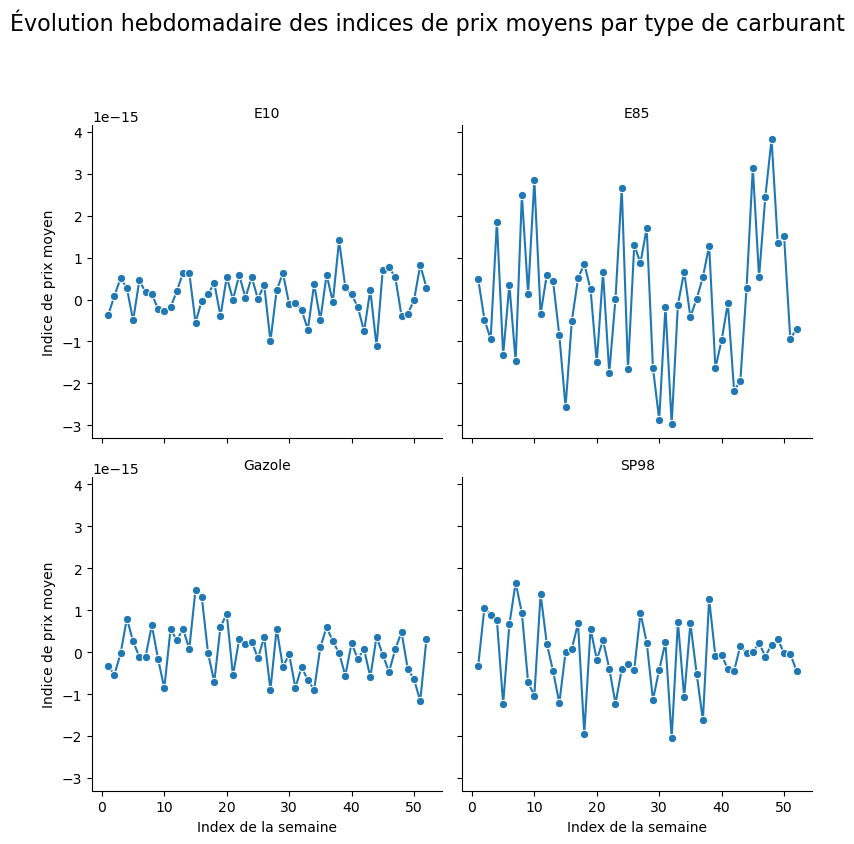

In [76]:
# Créer un graphique avec Seaborn FacetGrid
g = sns.FacetGrid(
    df_essence1,
    col='carburant_nom',  # Une colonne par type de carburant
    col_wrap=2,                      # Nombre maximum de colonnes par ligne
    height=4,                        # Hauteur des graphiques
    sharex=True,                     # Partager l'axe X pour faciliter la comparaison
    sharey=True                      # Partager l'axe Y pour faciliter la comparaison
)

# Ajouter des lignes dans chaque sous-graphe
g.map(sns.lineplot, 'index_semaine', 'indice_prix_recentre', marker='o')

# Configurations du graphique
g.set_axis_labels("Index de la semaine", "Indice de prix moyen")
g.set_titles("{col_name}")
g.fig.suptitle("Évolution hebdomadaire des indices de prix moyens par type de carburant", y=1.05, fontsize=16)
g.tight_layout()

# Afficher le graphique
plt.show()

## Modélisation – Prévision du prix du jour suivant
#### Attendu #7

- Agrégation des prix par carburant et par jour

In [90]:
# Colonne 'Date' au format datetime
df_essence['date'] = pd.to_datetime(df_essence['date'])

# Extraction de la date sans l'heure
df_essence['date'] = df_essence['date'].dt.date

# Agrégration du prix moyen par carburant et par date
df_national = df_essence.groupby(['date', 'carburant_nom'])['prix'].mean().reset_index()

# Vérification
print(df_national.head())




         date carburant_nom      prix
0  2023-01-01           E10  1.825184
1  2023-01-01           E85  1.139915
2  2023-01-01        Gazole  1.932416
3  2023-01-01          SP98  1.925719
4  2023-01-02           E10  1.790054


#### Ajout des variables retardées (lag features)
On utilise des prix des jours précédents comme variables d’entrée pour prédire le prix du lendemain.

In [93]:
# Création des features avec les prix des jours précédents (lags)
def create_lag_features(df_c, lags=[1, 2, 3, 7]):
    df_c = df_c.copy()
    for lag in lags:
        df_c[f'Price_lag_{lag}'] = df_c.groupby('carburant_nom')['prix'].shift(lag)
    return df_c

df_national = create_lag_features(df_national)
df_national.dropna(inplace=True)  # Supprime les lignes avec NaN générés par le décalage


#### Entraînement du modèle de prévision
- On entraîne un modèle de régression sur chaque carburant.

In [96]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


In [98]:
df_essence = df_essence.assign(prix=lambda df_essence: df_essence['prix']* 1000)
df_essence.head(2)

,id_pdv,code_postal,population,latitude,longitude,date,carburant_id,carburant_nom,prix,année,mois,semaine,Average_Day_Price,Price_Index,index_semaine,indice_prix_recentre
0,1000001,1000,R,46.201,5.198,2023-01-02,1.0,Gazole,1867.0,2023.0,1.0,1,0.001867,100.0,1,0.0
1,1000001,1000,R,46.201,5.198,2023-01-05,1.0,Gazole,1877.0,2023.0,1.0,1,0.001877,100.0,1,0.0


In [100]:

# Fonction d'entraînement pour chaque carburant
def train_model_for_fuel(df, fuel_type):
    df_fuel = df[df['carburant_nom'] == fuel_type]  # Filtrer par type de carburant
    
    # Sélection des features (X) et la cible (y)
    X = df_fuel[['Price_lag_1', 'Price_lag_2', 'Price_lag_3', 'Price_lag_7']]
    y = df_fuel['prix'] 

    # Séparation les données en train/test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    
    # Entraînement d'un modèle RandomForest
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    # Prédictions
    y_pred = model.predict(X_test)
    
    # Calcul des métriques d'évaluation
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    # le modèle et les métriques
    return model, mae, rmse, y_test, y_pred

# Séparation en train et test sur l'ensemble des données
train, test = train_test_split(df_national, test_size=0.2, shuffle=False)

# Dictionnaire pour stocker les résultats
results = {}


In [102]:
# Boucle pour entraîner le modèle pour chaque carburant
for fuel in df_national['carburant_nom'].unique():
    model, mae, rmse, y_test, y_pred = train_model_for_fuel(train, fuel) 
    results[fuel] = {'model': model, 'MAE': mae, 'RMSE': rmse, 'y_test': y_test, 'y_pred': y_pred}
    
    # Affichage des résultats pour chaque carburant
    print(f"{fuel} - MAE: {mae:.4f}, RMSE: {rmse:.4f}")

E10 - MAE: 0.0125, RMSE: 0.0157
E85 - MAE: 0.0069, RMSE: 0.0091
Gazole - MAE: 0.0142, RMSE: 0.0192
SP98 - MAE: 0.0102, RMSE: 0.0140


In [112]:
import pandas as pd

# Transformer les résultats en une liste de dictionnaires
results_table = []

for fuel_type, result in results.items():
    for prix_reel, prix_prevu in zip(result['y_test'], result['y_pred']):
        results_table.append({
            "carburant": fuel_type,
            "prix_reel": prix_reel,
            "prix_prevu": prix_prevu,
            "MAE": result['MAE'],
            "RMSE": result['RMSE']
        })

# Créer le DataFrame
df_results_table = pd.DataFrame(results_table)

# Afficher un aperçu des résultats sous forme de tableau
print(df_results_table.head())


  carburant  prix_reel  prix_prevu       MAE      RMSE
0       E10   1.933442    1.935057  0.012539  0.015712
1       E10   1.937883    1.941779  0.012539  0.015712
2       E10   1.953335    1.930800  0.012539  0.015712
3       E10   1.939953    1.943565  0.012539  0.015712
4       E10   1.947016    1.941722  0.012539  0.015712


In [120]:
# Affichage des résultats sous forme de tableau pour chaque type de carburant
for fuel_type, result in results.items():
    # Créer un DataFrame spécifique pour ce carburant
    df_fuel_results = pd.DataFrame({
        "prix_reel": result["y_test"],
        "prix_prevu": result["y_pred"],
        "MAE": [result["MAE"]] * len(result["y_test"]),  # Ajouter une colonne constante pour MAE
        "RMSE": [result["RMSE"]] * len(result["y_test"])  # Ajouter une colonne constante pour RMSE
    })

    print(f"\n=== Tableau des résultats pour le carburant: {fuel_type} ===")
    print(df_fuel_results.head(10))  # Affiche les 10 premières lignes



=== Tableau des résultats pour le carburant: E10 ===
     prix_reel  prix_prevu       MAE      RMSE
944   1.933442    1.935057  0.012539  0.015712
948   1.937883    1.941779  0.012539  0.015712
952   1.953335    1.930800  0.012539  0.015712
956   1.939953    1.943565  0.012539  0.015712
960   1.947016    1.941722  0.012539  0.015712
964   1.945696    1.941701  0.012539  0.015712
968   1.962699    1.938947  0.012539  0.015712
972   1.913743    1.940263  0.012539  0.015712
976   1.931545    1.926699  0.012539  0.015712
980   1.945945    1.923028  0.012539  0.015712

=== Tableau des résultats pour le carburant: E85 ===
     prix_reel  prix_prevu       MAE      RMSE
941   1.052351    1.057613  0.006927  0.009148
945   1.026171    1.029255  0.006927  0.009148
949   1.040223    1.044633  0.006927  0.009148
953   1.052960    1.051253  0.006927  0.009148
957   1.047286    1.050252  0.006927  0.009148
961   1.051745    1.050465  0.006927  0.009148
965   1.051150    1.057683  0.006927  0.009148

- Globalement, toutes les erreurs sont relativement faibles, ce qui signifie que le modèle est performant pour prédire les prix des carburants. 
- Les deux métriques (MAE et RMSE) sont cohérentes.
- Le modèle semble être légèrement meilleur pour prédire les prix d'E85 par rapport aux autres carburants, avec les erreurs les plus faibles.
- On peut conclure que le modèle de prédiction est relativement efficace et que les erreurs sont faibles, ce qui est un bon signe de performance. 

#### Visualisation des résultats
- On compare les prix réels et prédits avec un graphique de dispersion.

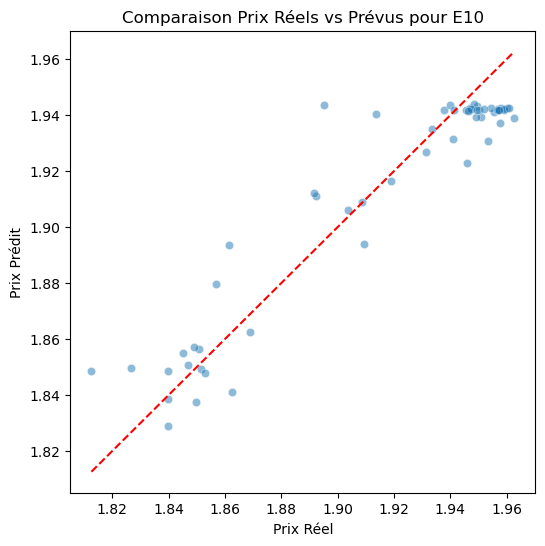

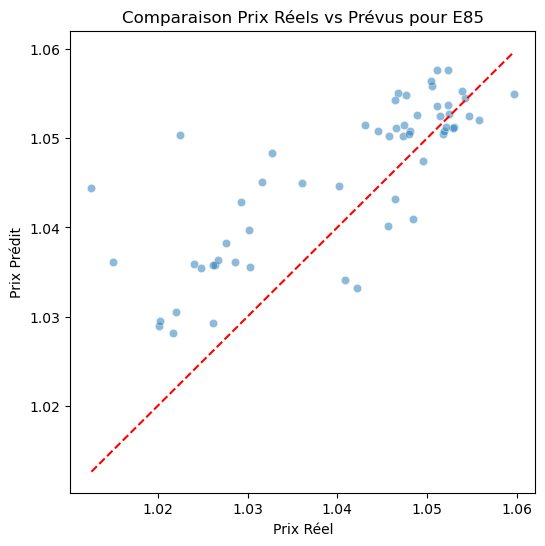

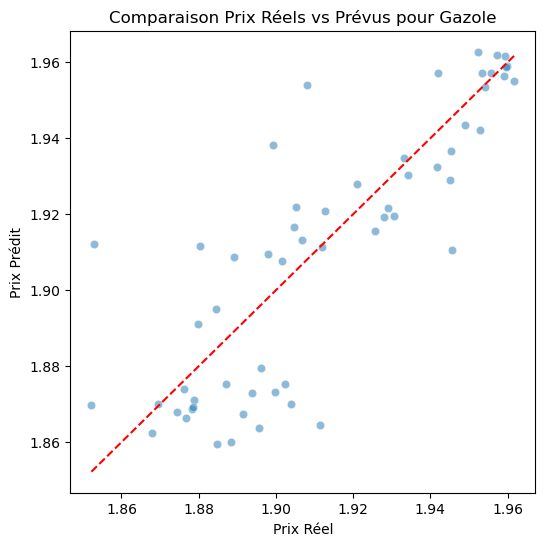

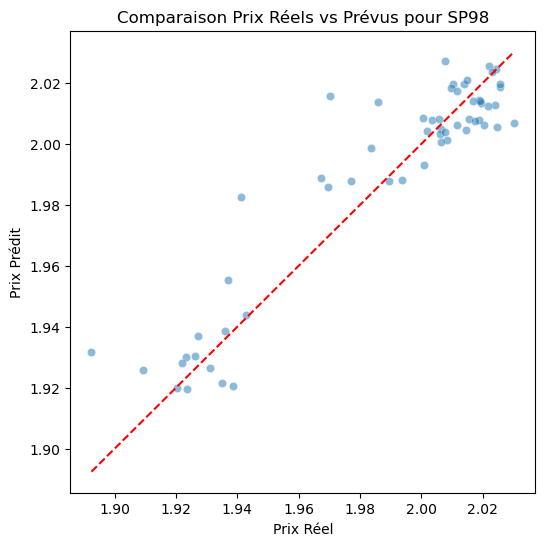

In [104]:
for fuel, res in results.items():
    plt.figure(figsize=(6, 6))
    sns.scatterplot(x=res['y_test'], y=res['y_pred'], alpha=0.5)
    plt.xlabel("Prix Réel")
    plt.ylabel("Prix Prédit")
    plt.title(f"Comparaison Prix Réels vs Prévus pour {fuel}")
    plt.plot([min(res['y_test']), max(res['y_test'])], [min(res['y_test']), max(res['y_test'])], '--', color='red')  # Ligne diagonale parfaite
    plt.show()


#### Interprétation
Ces graphiques indiquent que le modèle de prévision des prix pour le SP98 est extrêmement performant par rapport aux autres avec une très forte correspondance entre les prix réels observés et les prix prévus même si les autres types de carburants témoignent aussi d'une correlation entre les deux prix. La dispersion limitée des points autour de la ligne de tendance témoigne d'une grande précision du modèle pour ce carburant spécifique.

#### Bonus-Catographie

In [137]:
pip install geopandas

   ---------------------------------------- 0.0/323.6 kB ? eta -:--:--
   ------------- -------------------------- 112.6/323.6 kB 3.2 MB/s eta 0:00:01
   ------------------------------------- -- 307.2/323.6 kB 3.8 MB/s eta 0:00:01
   ---------------------------------------- 323.6/323.6 kB 3.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/16.2 MB ? eta -:--:--
   ---------------------------------------- 0.2/16.2 MB 3.9 MB/s eta 0:00:05
    --------------------------------------- 0.4/16.2 MB 3.7 MB/s eta 0:00:05
   - -------------------------------------- 0.6/16.2 MB 4.3 MB/s eta 0:00:04
   - -------------------------------------- 0.7/16.2 MB 4.3 MB/s eta 0:00:04
   -- ------------------------------------- 1.0/16.2 MB 4.1 MB/s eta 0:00:04
   -- ------------------------------------- 1.1/16.2 MB 4.2 MB/s eta 0:00:04
   --- ------------------------------------ 1.4/16.2 MB 4.1 MB/s eta 0:00:04
   --- ------------------------------------ 1.5/16.2 MB 4.1 MB/s eta 0:00:04
   

In [141]:
pip install folium


   ---------------------------------------- 0.0/110.5 kB ? eta -:--:--
   -------------- ------------------------ 41.0/110.5 kB 991.0 kB/s eta 0:00:01
   ---------------------------------------- 110.5/110.5 kB 1.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [143]:
import geopandas as gpd
import folium
from folium.plugins import HeatMap


In [151]:
# Charger les données géographiques des régions
re = gpd.read_file(r"C:\Users\Lenovo\Downloads\fichier.json")
re

,source,id,name,geometry
0,https://simplemaps.com,FRHDF,Hauts de France,"POLYGON ((4.21594 49.95441, 4.21805 49.93804, ..."
1,https://simplemaps.com,FRGES,Grand Est,"POLYGON ((3.4779 48.8501, 3.49234 48.87128, 3...."
2,https://simplemaps.com,FRPAC,Provence Alpes Côte d'Azu,"MULTIPOLYGON (((4.2059 43.45991, 4.23128 43.47..."
3,https://simplemaps.com,FRARA,Auvergne Rhône Alpes,"POLYGON ((6.62939 45.12355, 6.62815 45.12345, ..."
4,https://simplemaps.com,FRBFC,Bourgogne Franche Comté,"POLYGON ((3.39538 48.41174, 3.41289 48.40205, ..."
5,https://simplemaps.com,FROCC,Occitanie,"MULTIPOLYGON (((4.65784 44.28172, 4.66728 44.2..."
6,https://simplemaps.com,FRPDL,Pays de la Loire,"MULTIPOLYGON (((-1.07908 48.49869, -1.02872 48..."
7,https://simplemaps.com,FRBRE,Bretagne,"MULTIPOLYGON (((-1.07908 48.49869, -1.07928 48..."
8,https://simplemaps.com,FRNOR,Normandie,"POLYGON ((1.37307 50.06572, 1.51638 50.00067, ..."
9,https://simplemaps.com,FR20R,Corse,"MULTIPOLYGON (((9.3943 41.84797, 9.40301 41.77..."


In [165]:
# Convertir la colonne 'id' en chaîne de caractères
re['id'] = re['id'].astype(str)

# Calculer l'indice de prix moyen par région et par type de carburant
Price_Index_reg = df_essence.groupby(['carburant_nom', 'code_postal'])['Price_Index'].mean().reset_index()

# Convertir la colonne 'Code_Localite' en chaîne de caractères
Price_Index_reg ['code_postal'] = Price_Index_reg ['code_postal'].astype(str)

# Fonction pour créer une carte de chaleur pour un type de carburant
def create_heatmap(data, carburant_nom):
    # Filtrer les données pour le type de carburant
    data_filtered = data[data['carburant_nom'] == carburant_nom]
    
    # Joindre les données géographiques avec les indices de prix
    geo_data = re.merge(data_filtered, left_on='id', right_on='code_postal')
    
    # Créer la carte
    m = folium.Map(location=[46.603354, 1.888334], zoom_start=6)
    
    # Ajouter les régions à la carte avec une carte de chaleur (choropleth)
    folium.Choropleth(
        geo_data=geo_data, name='choropleth',
        data=geo_data,
        columns=['id', 'Price_Index'],
        key_on='feature.properties.id',  # Assurez-vous que "id" est bien une propriété dans le GeoJSON
        fill_color='YlOrRd',
        fill_opacity=0.7,
        line_opacity=0.2,
        legend_name='Price_Index'
    ).add_to(m)

    
    